In [4]:
import pandas as pd

In [ ]:
#PUNTO 1: VERIFICARE DIMENSIONI DEL DATASET E RELATIVI METADATI

In [ ]:
#caricamento del dataset

In [6]:
df = pd.read_csv("Prova Python.csv")

In [8]:
#dimensioni del dataset
print("Dimensioni:", df.shape)

Dimensioni: (429435, 67)


In [32]:
#intervallo temporale del dataset
print("Data iniziale:", df['date'].min())
print("Data finale:", df['date'].max())

Data iniziale: 2020-01-01
Data finale: 2024-08-14


In [9]:
#colonne presenti
print("Colonne:", df.columns.tolist())

Colonne: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred'

In [10]:
#tipi di dato
print("Tipi di dato:\n", df.dtypes)

Tipi di dato:
 iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
population                                   int64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object


In [11]:
#valori mancanti
print("Valori mancanti:\n", df.isnull().sum())

Valori mancanti:
 iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64


In [ ]:
#PUNTO 2: PER OGNI CONTINENTE, NUMERO DI CASI TOTALI E PERCENTUALE SUL TOTALE GLOBALE

In [30]:
#nomi dei continenti
print(df['continent'].unique())

['Asia' nan 'Europe' 'Africa' 'Oceania' 'North America' 'South America']


In [31]:
#nomi dei paesi
print(df['location'].unique())

['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe' 'European Union (27)' 'Faroe Islands' 'Falkland Islands' 'Fiji'
 'Finland' 'France' 'French Guiana' 'Fr

In [12]:
#filtro righe con dati aggregati per continente
continents = df[df['location'].isin(['Africa','Asia','Europe','North America','South America','Oceania'])]

In [13]:
#prendo solo l'ultima data disponibile per ogni continente
latest_by_continent = continents.sort_values('date').groupby('location').last()

In [16]:
#numero casi totali e percentuali
total_global_cases = latest_by_continent['total_cases'].sum()
latest_by_continent['percentuale_mondiale'] = (latest_by_continent['total_cases'] / total_global_cases) * 100

print(latest_by_continent[['total_cases', 'percentuale_mondiale']])

               total_cases  percentuale_mondiale
location                                        
Africa          13145380.0              1.694283
Asia           301499099.0             38.859648
Europe         252916868.0             32.597976
North America  124492666.0             16.045624
Oceania         15003352.0              1.933754
South America   68809418.0              8.868716


In [ ]:
#PUNTO 3: ITALIA NEL 2022: TREND TOTALE E NUOVI CASI

In [17]:
#filtro Italia e dati del 2022
italia_2022 = df[(df['location'] == 'Italy') & (df['date'].str.startswith('2022'))]

In [18]:
#rimuovo righe senza misurazioni
italia_2022 = italia_2022.dropna(subset=['new_cases', 'total_cases'])

import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


<Figure size 640x480 with 0 Axes>

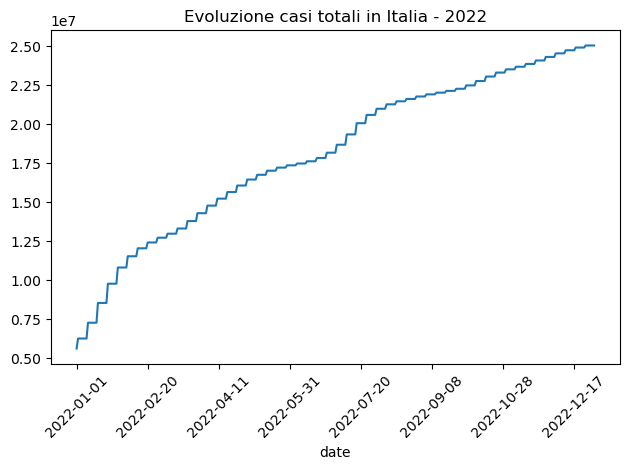

In [19]:
#a. evoluzione casi totali
plt.figure()
italia_2022.plot(x='date', y='total_cases', title='Evoluzione casi totali in Italia - 2022', legend=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

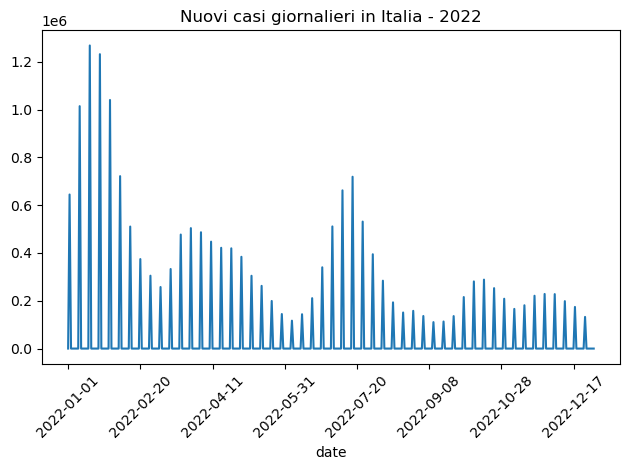

In [20]:
#b. nuovi casi giornalieri
plt.figure()
italia_2022.plot(x='date', y='new_cases', title='Nuovi casi giornalieri in Italia - 2022', legend=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#PUNTO 4: BOXPLOT ICU - ITALIA, GERMANIA, FRANCIA (mag 2022 - apr 2023)

In [21]:
#filtro i paesi e il periodo
icu_df = df[df['location'].isin(['Italy', 'Germany', 'France'])]
icu_df = icu_df[(icu_df['date'] >= '2022-05-01') & (icu_df['date'] <= '2023-04-30')]

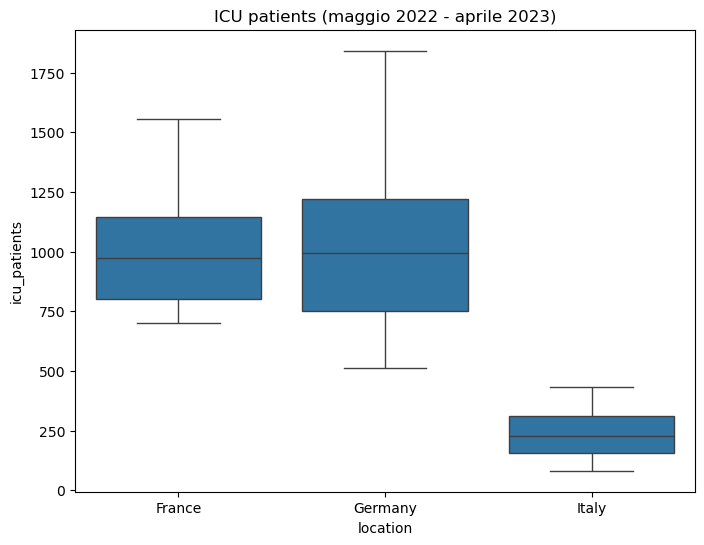

In [23]:
#boxplot pazienti ICU
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=icu_df, x='location', y='icu_patients')
plt.title("ICU patients (maggio 2022 - aprile 2023)")
plt.show()

In [24]:
#commento
icu_means = icu_df.groupby('location')['icu_patients'].mean()
print("Media pazienti in ICU:\n", icu_means)

Media pazienti in ICU:
 location
France      998.379104
Germany    1022.386301
Italy       231.254795
Name: icu_patients, dtype: float64


In [ ]:
#PARTE 5: SOMMA DEI PAZIENTI OSPEDALIZZATI NEL 2021 ITALIA, GERMANIA, FRANCIA, SPAGNA

In [25]:
#paesi e periodo
hosp_df = df[df['location'].isin(['Italy', 'Germany', 'France', 'Spain'])]
hosp_df = hosp_df[hosp_df['date'].str.startswith('2021')]

In [26]:
#somma dei pazienti ospedalizzati
hosp_sum = hosp_df.groupby('location')['hosp_patients'].sum()
print("Totale pazienti ospedalizzati nel 2021:\n", hosp_sum)

Totale pazienti ospedalizzati nel 2021:
 location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


In [33]:
#gestione valori nulli
hosp_df_interpolated = hosp_df.copy()
hosp_df_interpolated['hosp_patients'] = hosp_df_interpolated['hosp_patients'].interpolate()

#Per non compromettere il calcolo della somma totale dei pazienti ospedalizzati, 
#è stato utilizzato il metodo .interpolate() di Pandas, che permette di stimare i valori mancanti 
#in modo coerente con l’andamento temporale dei dati.